In [3]:
import numpy as np
import matplotlib.pyplot as plt
# Define parameters
h = 0.1 # step size
x_start, x_end = 0, 2
num_steps = int((x_end - x_start) / h)
x_values = np.linspace(x_start, x_end, num_steps +
1)
y_values = np.zeros(num_steps + 1)
# Initial condition
y_values[0] = 1 # y(0) = 1
# Function representing dy/dx = -2y
def f(x, y):
    return -2 * y

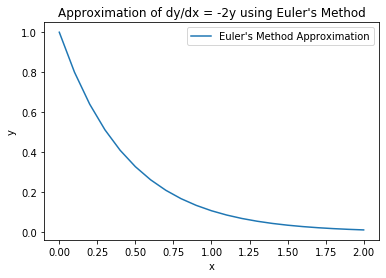

In [8]:
# Implement Euler's method
for i in range(num_steps):
    y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])
    
# Plot the results
plt.plot(x_values, y_values, label="Euler's Method Approximation")
plt.xlabel('x')
plt.ylabel('y')
plt.title("Approximation of dy/dx = -2y using Euler's Method")
plt.legend()
plt.show()


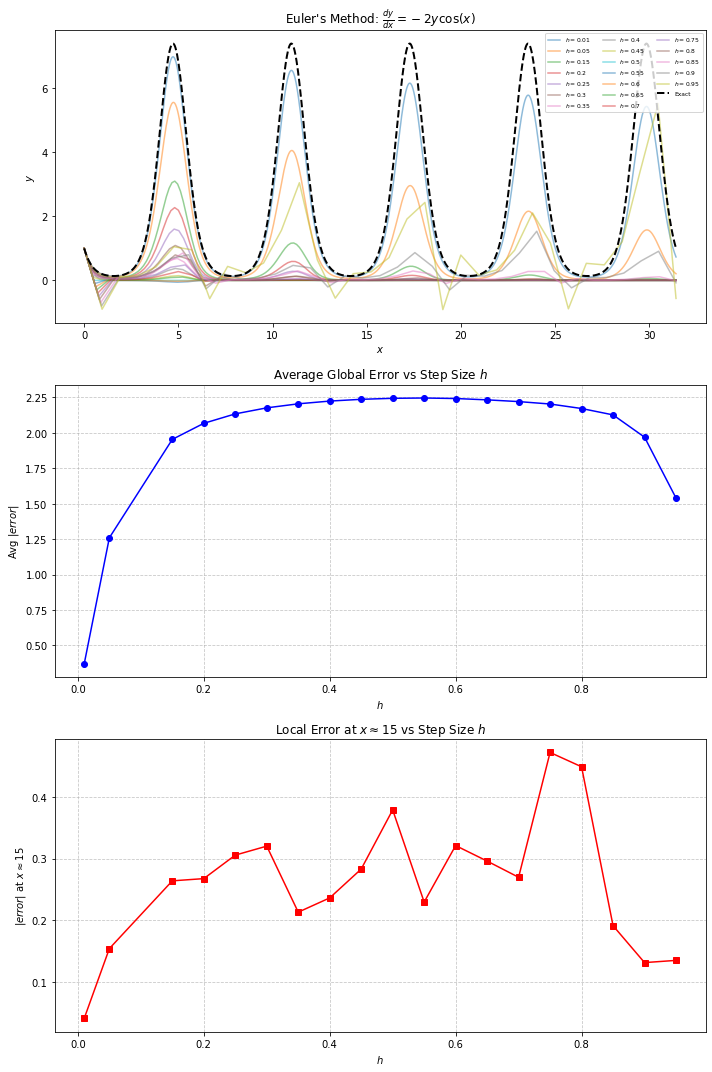

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
x_start, x_end = 0, 10 * np.pi

def f(x, y):
    return -2 * y * np.cos(x)         # dy/dx = -2y * cos(x)

def exact(x):
    return np.exp(-2 * np.sin(x))     # analytical solution

# Step sizes
h_values = [0.01, 0.05, 0.15, 0.2, 0.25, 0.3, 0.35,
            0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7,
            0.75, 0.8, 0.85, 0.9, 0.95]

avg_errors = []
local_errors_at_15 = []

# Create a single figure with 3 subplots arranged vertically
fig, axes = plt.subplots(3, 1, figsize=(10, 15))
ax1, ax2, ax3 = axes

for h in h_values:
    num_steps = int((x_end - x_start) / h)
    x_vals = np.linspace(x_start, x_end, num_steps + 1)
    y_vals = np.zeros(num_steps + 1)
    y_vals[0] = 1.0

    # Euler loop
    for i in range(num_steps):
        y_vals[i+1] = y_vals[i] + h * f(x_vals[i], y_vals[i])

    # Exact solution at same x points
    y_exact = exact(x_vals)

    # Global error (average)
    error = np.abs(y_vals - y_exact)
    avg_errors.append(np.mean(error))

    # Local error near x = 15
    idx = np.argmin(np.abs(x_vals - 15.0))
    local_errors_at_15.append(np.abs(y_vals[idx] - y_exact[idx]))

    # Plot results on first axis
    ax1.plot(x_vals, y_vals, alpha=0.5, label=f'$h={h}$')

# Finish Subplot 1: All Euler runs
x_fine = np.linspace(x_start, x_end, 5000)
y_fine = exact(x_fine)
ax1.plot(x_fine, y_fine, 'k--', linewidth=2, label='Exact')
ax1.set_title(r"Euler's Method: $\frac{dy}{dx} = -2y \cos(x)$")
ax1.set_xlabel('$x$')
ax1.set_ylabel('$y$')
ax1.legend(fontsize=6, ncol=3)

# Finish Subplot 2: Avg error vs h
ax2.plot(h_values, avg_errors, 'o-', color='blue')
ax2.set_title(r'Average Global Error vs Step Size $h$')
ax2.set_xlabel('$h$')
ax2.set_ylabel(r'Avg $|error|$')
ax2.grid(True, linestyle='--', alpha=0.7)

# Finish Subplot 3: Local error at x≈15 vs h
ax3.plot(h_values, local_errors_at_15, 's-', color='red')
ax3.set_title(r'Local Error at $x \approx 15$ vs Step Size $h$')
ax3.set_xlabel('$h$')
ax3.set_ylabel(r'$|error|$ at $x \approx 15$')
ax3.grid(True, linestyle='--', alpha=0.7)

# Adjust layout and save
plt.tight_layout()